Sample Boston Real Estate Dataset:

Sale probability statistics:


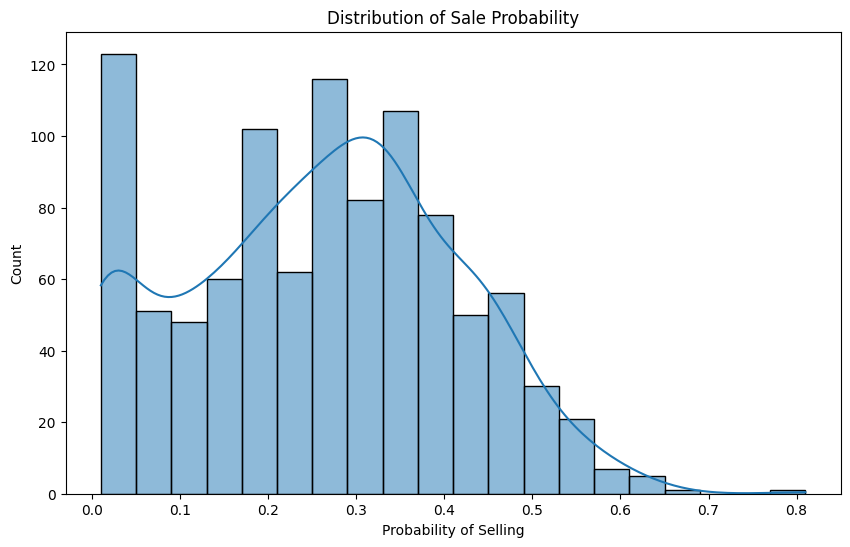

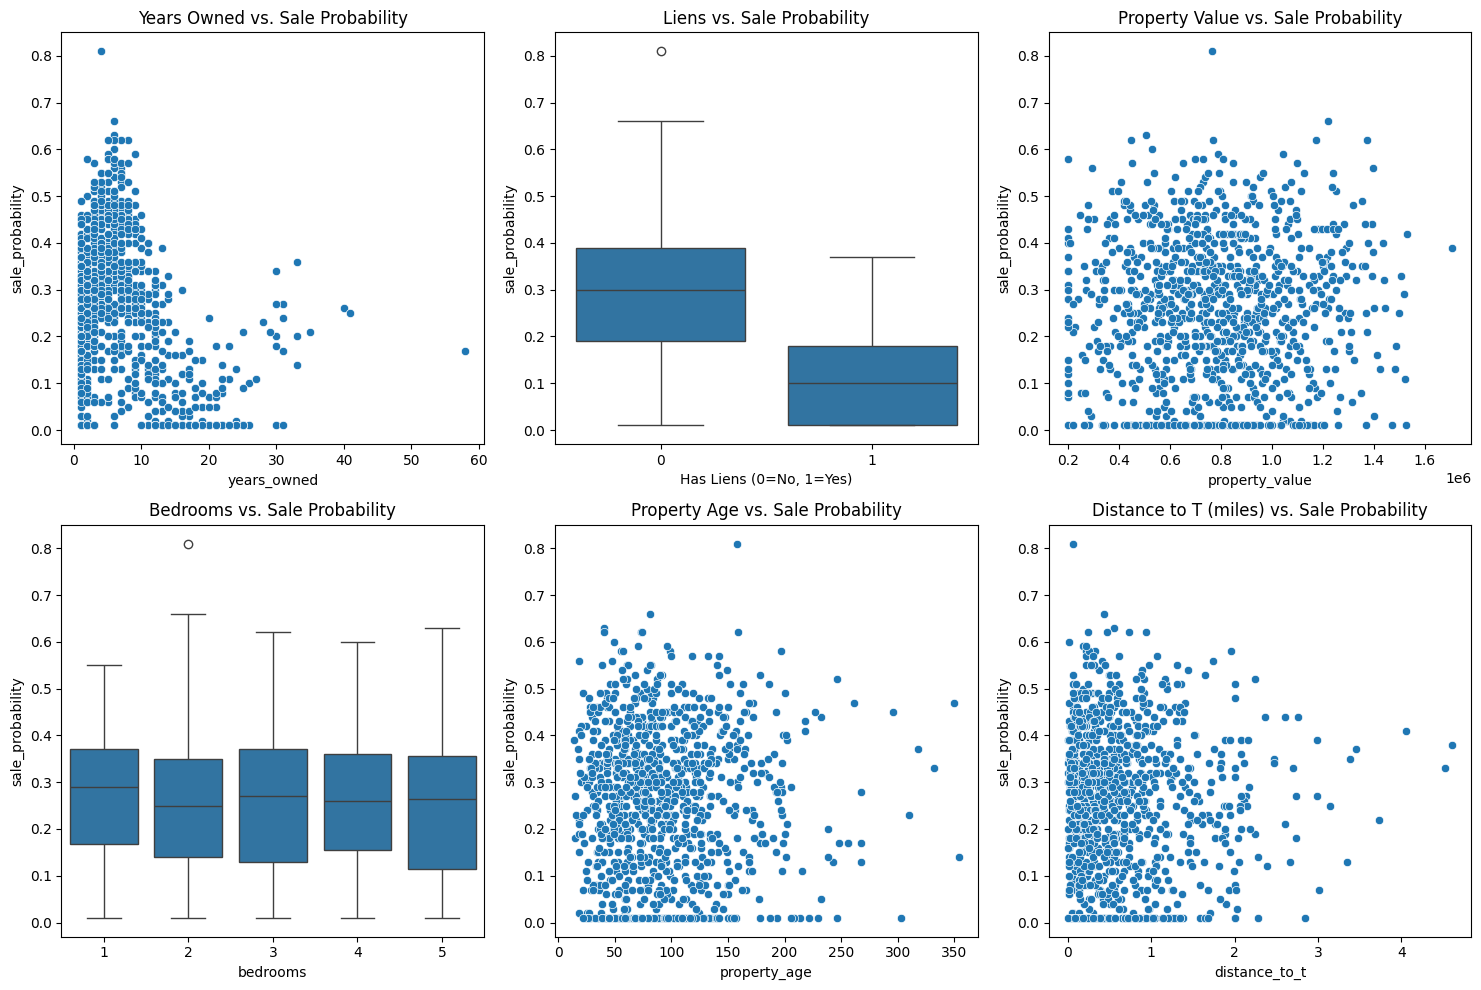

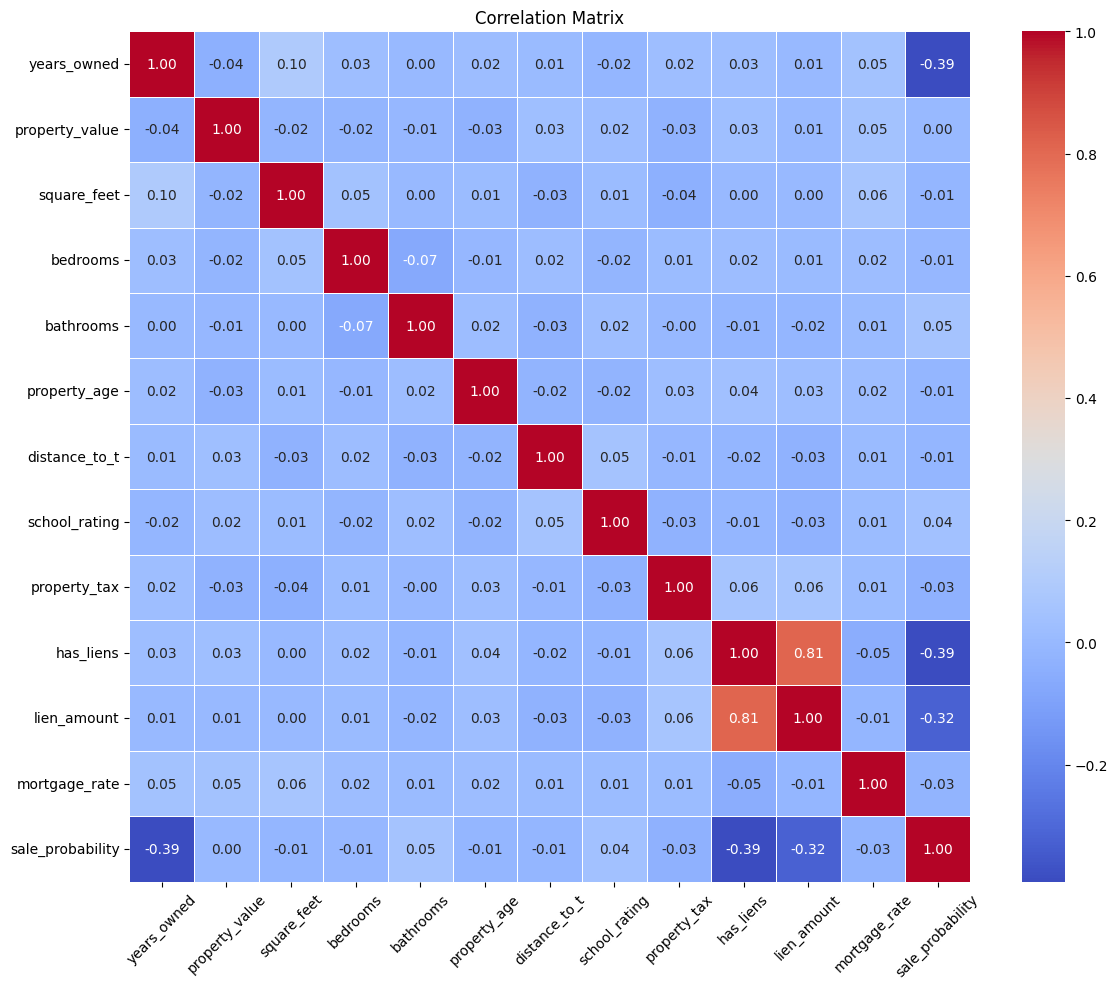

Dataset saved to 'boston_real_estate_sale_probability.csv'


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random

# Set random seed for reproducibility
np.random.seed(42)

# Define Boston neighborhoods
boston_neighborhoods = [
    'Back Bay', 'Beacon Hill', 'North End', 'South End', 'Fenway',
    'Allston', 'Brighton', 'Jamaica Plain', 'Roxbury', 'Dorchester',
    'South Boston', 'East Boston', 'Charlestown', 'West Roxbury', 
    'Hyde Park', 'Mattapan', 'Roslindale'
]

# Function to create synthetic Boston real estate data
def generate_boston_real_estate_data(num_samples=500):
    # Current date for reference
    current_date = datetime.now()
    
    # Generate data
    data = {
        # Length of homeownership (years since last purchase)
        'years_owned': np.random.exponential(scale=7, size=num_samples).astype(int) + 1,
        
        # Property characteristics
        'property_value': np.random.normal(loc=750000, scale=300000, size=num_samples),
        'square_feet': np.random.normal(loc=1800, scale=700, size=num_samples),
        'bedrooms': np.random.choice([1, 2, 3, 4, 5], size=num_samples, p=[0.1, 0.25, 0.4, 0.2, 0.05]),
        'bathrooms': np.random.choice([1, 1.5, 2, 2.5, 3, 3.5, 4], size=num_samples, 
                                     p=[0.15, 0.2, 0.3, 0.15, 0.1, 0.05, 0.05]),
        'property_age': np.random.gamma(shape=3, scale=30, size=num_samples) + 5,
        
        # Location characteristics
        'neighborhood': np.random.choice(boston_neighborhoods, size=num_samples),
        'distance_to_t': np.random.exponential(scale=0.7, size=num_samples),
        'school_rating': np.random.normal(loc=7, scale=1.5, size=num_samples),
        
        # Financial characteristics
        'property_tax': np.random.normal(loc=5000, scale=2000, size=num_samples),
        'has_liens': np.random.choice([0, 1], size=num_samples, p=[0.85, 0.15]),
        'lien_amount': np.zeros(num_samples),
        'mortgage_rate': np.random.normal(loc=4.5, scale=1.5, size=num_samples),
        'income_to_mortgage_ratio': np.random.normal(loc=3.5, scale=1.2, size=num_samples),
        
        # Market conditions
        'market_inventory_months': np.random.normal(loc=3.5, scale=1.5, size=num_samples),
        'avg_days_on_market': np.random.gamma(shape=2, scale=15, size=num_samples) + 10,
    }
    
    # Convert to DataFrame
    df = pd.DataFrame(data)
    
    # Clean up and transform data
    df['property_value'] = np.maximum(200000, df['property_value']).astype(int)
    df['square_feet'] = np.maximum(400, df['square_feet']).astype(int)
    df['property_age'] = np.maximum(0, df['property_age']).astype(int)
    df['school_rating'] = np.clip(df['school_rating'], 1, 10).round(1)
    df['property_tax'] = np.maximum(1000, df['property_tax']).astype(int)
    df['distance_to_t'] = np.round(df['distance_to_t'], 2)
    df['mortgage_rate'] = np.clip(df['mortgage_rate'], 2, 8).round(2)
    df['income_to_mortgage_ratio'] = np.maximum(0.5, df['income_to_mortgage_ratio']).round(2)
    df['market_inventory_months'] = np.maximum(0.5, df['market_inventory_months']).round(1)
    df['avg_days_on_market'] = np.maximum(1, df['avg_days_on_market']).astype(int)
    
    # Create lien amount for properties with liens
    df.loc[df['has_liens'] == 1, 'lien_amount'] = np.random.gamma(
        shape=2, scale=5000, size=df['has_liens'].sum())
    df['lien_amount'] = df['lien_amount'].astype(int)
    
    # Create last transaction date based on years owned
    df['last_transaction_date'] = df['years_owned'].apply(
        lambda x: (current_date - timedelta(days=365 * x)).strftime('%Y-%m-%d'))
    
    # Calculate the probability of selling
    # This is a simplified model that combines several factors
    df['sale_probability'] = (
        # Base probability decreases with length of ownership but peaks around 5-7 years
        0.4 * np.exp(-((df['years_owned'] - 6) ** 2) / 50) +
        
        # NEW: Elderly homeowner effect - increased probability after 25 years of ownership
        0.25 * np.clip((df['years_owned'] - 25) / 5, 0, 1) +
        
        # Liens decrease probability of selling
        -0.2 * (df['has_liens']) +
        
        # Financial factors
        -0.1 * np.clip((df['property_tax'] - 5000) / 10000, -0.1, 0.1) +
        0.1 * np.clip((df['income_to_mortgage_ratio'] - 3) / 5, -0.1, 0.1) +
        
        # Market conditions
        -0.1 * np.clip((df['market_inventory_months'] - 3) / 5, -0.1, 0.1) +
        -0.05 * np.clip((df['avg_days_on_market'] - 30) / 60, -0.05, 0.05) +
        
        # Neighborhood factor (random effect)
        0.1 * np.random.normal(0, 1, num_samples)
)
    
    # Clip probability between 0 and 1
    df['sale_probability'] = np.clip(df['sale_probability'], 0.01, 0.99).round(2)
    
    return df

# Generate the dataset
boston_real_estate = generate_boston_real_estate_data(1000)

# Display the first few rows
print("Sample Boston Real Estate Dataset:")
boston_real_estate.head()

# Basic statistics on sale probability
print("\nSale probability statistics:")
boston_real_estate['sale_probability'].describe()

# Plot distribution of sale probability
plt.figure(figsize=(10, 6))
sns.histplot(boston_real_estate['sale_probability'], bins=20, kde=True)
plt.title('Distribution of Sale Probability')
plt.xlabel('Probability of Selling')
plt.ylabel('Count')
plt.show()

# Visualize relationship between key features and sale probability
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.scatterplot(x='years_owned', y='sale_probability', data=boston_real_estate)
plt.title('Years Owned vs. Sale Probability')

plt.subplot(2, 3, 2)
sns.boxplot(x='has_liens', y='sale_probability', data=boston_real_estate)
plt.title('Liens vs. Sale Probability')
plt.xlabel('Has Liens (0=No, 1=Yes)')

plt.subplot(2, 3, 3)
sns.scatterplot(x='property_value', y='sale_probability', data=boston_real_estate)
plt.title('Property Value vs. Sale Probability')

plt.subplot(2, 3, 4)
sns.boxplot(x='bedrooms', y='sale_probability', data=boston_real_estate)
plt.title('Bedrooms vs. Sale Probability')

plt.subplot(2, 3, 5)
sns.scatterplot(x='property_age', y='sale_probability', data=boston_real_estate)
plt.title('Property Age vs. Sale Probability')

plt.subplot(2, 3, 6)
sns.scatterplot(x='distance_to_t', y='sale_probability', data=boston_real_estate)
plt.title('Distance to T (miles) vs. Sale Probability')

plt.tight_layout()
plt.show()

# Correlation matrix of numerical features with sale probability
correlation_cols = ['years_owned', 'property_value', 'square_feet', 'bedrooms', 
                    'bathrooms', 'property_age', 'distance_to_t', 'school_rating',
                    'property_tax', 'has_liens', 'lien_amount', 'mortgage_rate',
                    'sale_probability']

plt.figure(figsize=(12, 10))
correlation = boston_real_estate[correlation_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save the dataset to CSV
boston_real_estate.to_csv('boston_real_estate_sale_probability.csv', index=False)
print("Dataset saved to 'boston_real_estate_sale_probability.csv'")

# Step 5: Train Machine Learning Models

Step 5: Training Machine Learning Models
Training data shape: (750, 15)
Testing data shape: (250, 15)

Training Linear Regression...
Train RMSE: 0.1288
Test RMSE: 0.1239
Test MAE: 0.0998
Test R²: 0.3210

Training Ridge Regression...
Train RMSE: 0.1288
Test RMSE: 0.1239
Test MAE: 0.0999
Test R²: 0.3206

Training Lasso Regression...
Train RMSE: 0.1337
Test RMSE: 0.1303
Test MAE: 0.1070
Test R²: 0.2490

Training Random Forest...
Train RMSE: 0.0389
Test RMSE: 0.1003
Test MAE: 0.0824
Test R²: 0.5548

Training Gradient Boosting...
Train RMSE: 0.0711
Test RMSE: 0.1028
Test MAE: 0.0833
Test R²: 0.5325

Model Performance Comparison:


,train_rmse,test_rmse,test_mae,test_r2
Linear Regression,0.128828,0.123916,0.099816,0.320965
Ridge Regression,0.128832,0.123948,0.099875,0.320613
Lasso Regression,0.133700,0.130314,0.107050,0.249035
Random Forest,0.038945,0.100333,0.082413,0.554831
Gradient Boosting,0.071081,0.102821,0.083261,0.532476


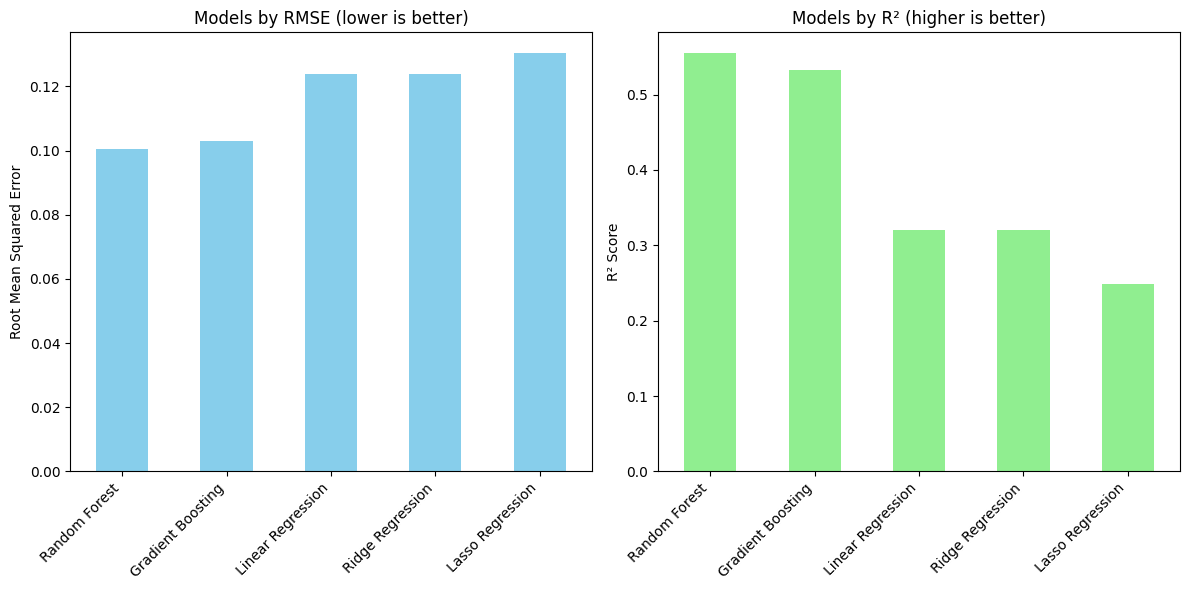


Analyzing feature importance for Random Forest


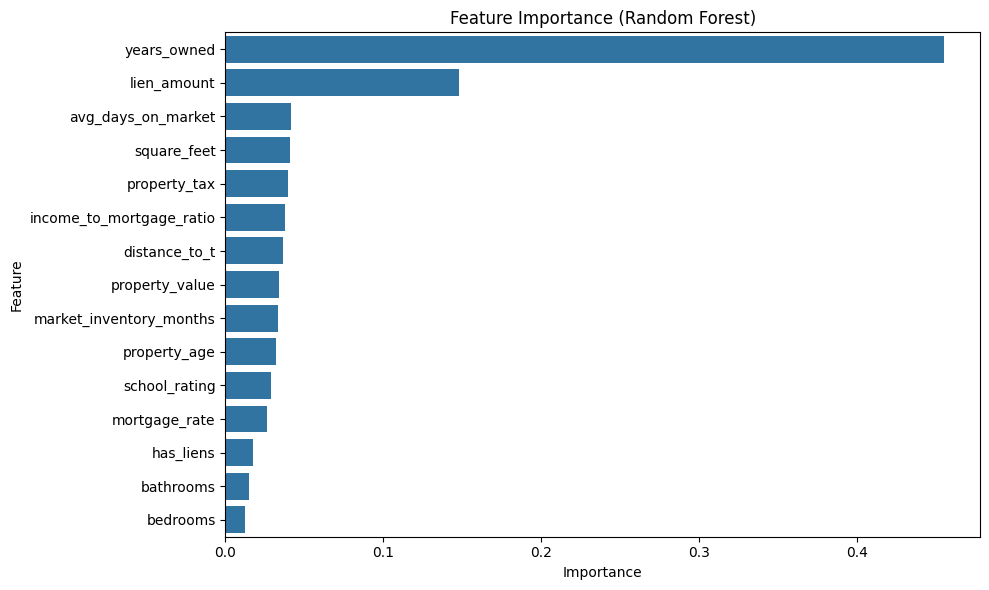

Top 5 most important features:
               Feature  Importance
0          years_owned    0.455355
10         lien_amount    0.148208
14  avg_days_on_market    0.041424
2          square_feet    0.041127
8         property_tax    0.039878

Sample predictions:
Sample 1:
  Years owned: 8.0
  Has liens: No
  Property value: $1,162,712.0
  True probability: 0.33
  Predicted probability: 0.35

Sample 2:
  Years owned: 7.0
  Has liens: No
  Property value: $739,594.0
  True probability: 0.33
  Predicted probability: 0.46

Sample 3:
  Years owned: 8.0
  Has liens: No
  Property value: $590,739.0
  True probability: 0.43
  Predicted probability: 0.40

Sample 4:
  Years owned: 1.0
  Has liens: No
  Property value: $1,005,066.0
  True probability: 0.16
  Predicted probability: 0.23

Sample 5:
  Years owned: 9.0
  Has liens: No
  Property value: $772,801.0
  True probability: 0.34
  Predicted probability: 0.35



In [7]:
# Create a new cell with this heading 
print("Step 5: Training Machine Learning Models")

# Split data into features and target
# Drop non-numeric or irrelevant columns
X = boston_real_estate.drop(['sale_probability', 'last_transaction_date', 'neighborhood'], axis=1)
y = boston_real_estate['sale_probability']

# Split into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Train multiple regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Define models to train
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)
    
    # Store results
    results[name] = {
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_r2': test_r2
    }
    
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Test MAE: {test_mae:.4f}")
    print(f"Test R²: {test_r2:.4f}")

# Create results dataframe
results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
display(results_df)

# Visualize model performance
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
results_df['test_rmse'].sort_values().plot(kind='bar', color='skyblue')
plt.title('Models by RMSE (lower is better)')
plt.ylabel('Root Mean Squared Error')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
results_df['test_r2'].sort_values(ascending=False).plot(kind='bar', color='lightgreen')
plt.title('Models by R² (higher is better)')
plt.ylabel('R² Score')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Feature importance analysis for best model (assuming Random Forest or Gradient Boosting)
best_model_name = results_df['test_r2'].idxmax()
print(f"\nAnalyzing feature importance for {best_model_name}")

if best_model_name in ['Random Forest', 'Gradient Boosting']:
    best_model = models[best_model_name]
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title(f'Feature Importance ({best_model_name})')
    plt.tight_layout()
    plt.show()
    
    print("Top 5 most important features:")
    print(feature_importance.head(5))
    
    # Check predictions for a few examples
    print("\nSample predictions:")
    sample_indices = np.random.choice(len(X_test), 5, replace=False)
    samples = X_test.iloc[sample_indices]
    true_values = y_test.iloc[sample_indices]
    predictions = best_model.predict(samples)
    
    for i, idx in enumerate(sample_indices):
        print(f"Sample {i+1}:")
        print(f"  Years owned: {samples.iloc[i]['years_owned']}")
        print(f"  Has liens: {'Yes' if samples.iloc[i]['has_liens'] == 1 else 'No'}")
        print(f"  Property value: ${samples.iloc[i]['property_value']:,}")
        print(f"  True probability: {true_values.iloc[i]:.2f}")
        print(f"  Predicted probability: {predictions[i]:.2f}")
        print()

# Step 6A: Feature Selection Based on Importance

In [8]:
print("Step 6A: Model Refinement - Feature Selection")

# Get top N important features from the best model
N = 6  # Number of top features to keep
top_features = feature_importance.head(N)['Feature'].values
print(f"Selected top {N} features: {', '.join(top_features)}")

# Create new datasets with only top features
X_train_reduced = X_train[top_features]
X_test_reduced = X_test[top_features]

# Train model with reduced features
reduced_model = RandomForestRegressor(n_estimators=100, random_state=42)
reduced_model.fit(X_train_reduced, y_train)

# Evaluate the reduced model
y_pred_reduced = reduced_model.predict(X_test_reduced)
reduced_rmse = np.sqrt(mean_squared_error(y_test, y_pred_reduced))
reduced_r2 = r2_score(y_test, y_pred_reduced)

# Compare with original model
print("\nModel Performance Comparison:")
print(f"Full model ({len(X_train.columns)} features) - RMSE: {results[best_model_name]['test_rmse']:.4f}, R²: {results[best_model_name]['test_r2']:.4f}")
print(f"Reduced model ({N} features) - RMSE: {reduced_rmse:.4f}, R²: {reduced_r2:.4f}")

# Is the simpler model better?
if reduced_r2 >= results[best_model_name]['test_r2'] - 0.01:  # Within 1% of original R²
    print("\n✅ The reduced model performs similarly with fewer features - prefer simpler model")
else:
    print("\n❌ The full model performs significantly better - keep all features")

Step 6A: Model Refinement - Feature Selection
Selected top 6 features: years_owned, lien_amount, avg_days_on_market, square_feet, property_tax, income_to_mortgage_ratio

Model Performance Comparison:
Full model (15 features) - RMSE: 0.1003, R²: 0.5548
Reduced model (6 features) - RMSE: 0.1022, R²: 0.5383

❌ The full model performs significantly better - keep all features


## Step 6B: Hyperparameter Tuning

In [9]:
print("Step 6B: Model Refinement - Hyperparameter Tuning")

from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Choose which feature set to use based on previous results
# (You would choose based on the outcome of Step 6A)
X_selected = X_train  # or X_train_reduced if the reduced model was better

# Create grid search
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='r2',
    verbose=1
)

# Fit the grid search (Note: This might take some time to run)
print("Running grid search (this might take a while)...")
grid_search.fit(X_selected, y_train)

# Print best parameters and score
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation R²: {grid_search.best_score_:.4f}")

# Evaluate the tuned model on test set
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)  # or X_test_reduced if using reduced features
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_r2 = r2_score(y_test, y_pred_tuned)

print(f"\nTuned model performance on test set - RMSE: {tuned_rmse:.4f}, R²: {tuned_r2:.4f}")
print(f"Original model performance - RMSE: {results[best_model_name]['test_rmse']:.4f}, R²: {results[best_model_name]['test_r2']:.4f}")

# Improvement percentage
r2_improvement = ((tuned_r2 - results[best_model_name]['test_r2']) / results[best_model_name]['test_r2']) * 100
print(f"R² improvement: {r2_improvement:.2f}%")

Step 6B: Model Refinement - Hyperparameter Tuning
Running grid search (this might take a while)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best cross-validation R²: 0.5691

Tuned model performance on test set - RMSE: 0.1003, R²: 0.5548
Original model performance - RMSE: 0.1003, R²: 0.5548
R² improvement: 0.00%


# Step 6C: Cross-Validation

In [10]:
print("Step 6C: Robust Model Evaluation - Cross-Validation")

from sklearn.model_selection import cross_val_score, KFold

# Setup cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Get the best model (from tuning step or original if better)
final_model = best_model  # This would be grid_search.best_estimator_ from previous step

# Run cross-validation
cv_scores = cross_val_score(
    final_model, 
    X,  # Use all data for CV
    y, 
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

# Check model stability
if cv_scores.std() < 0.05:
    print("\n✅ Model performance is consistent across different data splits")
else:
    print("\n⚠️ Model performance varies significantly with different data splits - consider more data or simpler model")

Step 6C: Robust Model Evaluation - Cross-Validation
Cross-Validation R² Scores: [0.54099478 0.55985577 0.54725199 0.60423633 0.61617789]
Mean R²: 0.5737
Standard Deviation: 0.0307

✅ Model performance is consistent across different data splits


# Step 6D: Model Interpretation - Partial Dependence Plots

Step 6D: Understanding the Model - Partial Dependence Plots
Creating partial dependence plots for: years_owned, lien_amount, avg_days_on_market


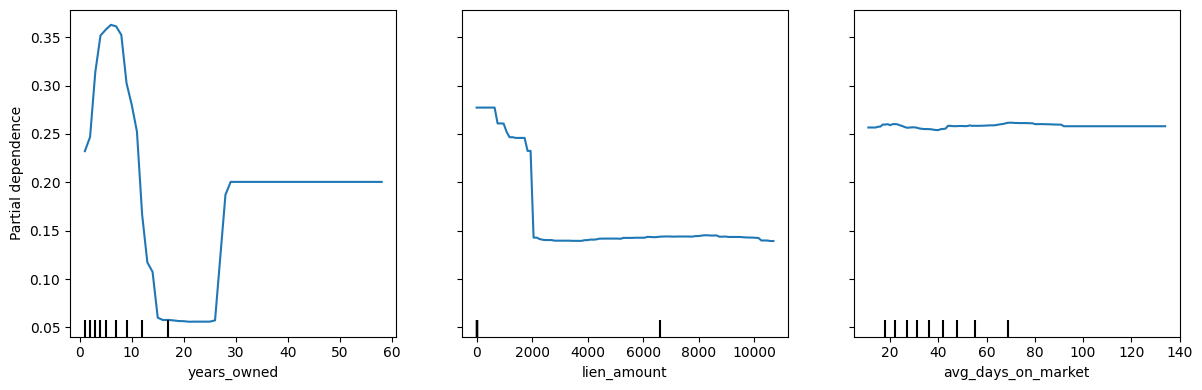

These plots show how each feature affects the prediction when other features are controlled for

To use SHAP for advanced interpretation, install it with: pip install shap


In [12]:
print("Step 6D: Understanding the Model - Partial Dependence Plots")

from sklearn.inspection import PartialDependenceDisplay

# Select a small number of top features for interpretation
features_to_plot = list(feature_importance.head(3)['Feature'].values)
print(f"Creating partial dependence plots for: {', '.join(features_to_plot)}")

# Create partial dependence plots (updated for newer scikit-learn versions)
fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    final_model, 
    X_train, 
    features=features_to_plot,
    n_jobs=-1,
    ax=ax
)
plt.tight_layout()
plt.show()

print("These plots show how each feature affects the prediction when other features are controlled for")

# Optional: SHAP values for deeper interpretation
try:
    import shap
    print("\nCalculating SHAP values for detailed feature impact...")
    
    # Create explainer
    explainer = shap.TreeExplainer(final_model)
    
    # Calculate SHAP values for a sample of the data (for speed)
    sample_indices = np.random.choice(len(X_test), min(50, len(X_test)), replace=False)
    shap_values = explainer.shap_values(X_test.iloc[sample_indices])
    
    # Summary plot
    shap.summary_plot(shap_values, X_test.iloc[sample_indices])
    
    print("SHAP values show how each feature contributes to pushing predictions higher or lower")
except ImportError:
    print("\nTo use SHAP for advanced interpretation, install it with: pip install shap")

# Step 7: Model Deployment Preparation

In [13]:
print("Step 7: Preparing for Deployment")

import pickle
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify numeric and categorical columns (if any)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        # Enable if you have categorical features
        # ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create full pipeline with preprocessing and model
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', final_model)
])

# Fit the pipeline on all data
full_pipeline.fit(X, y)

# Save the model
with open('boston_real_estate_sale_model.pkl', 'wb') as file:
    pickle.dump(full_pipeline, file)

print("Model saved to 'boston_real_estate_sale_model.pkl'")

# Example of how to use the saved model
print("\nExample prediction with saved model:")

# Load the model
with open('boston_real_estate_sale_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Create sample data (single property)
sample_property = {
    'years_owned': 30,
    'property_value': 850000,
    'square_feet': 2000,
    'bedrooms': 3,
    'bathrooms': 2.5,
    'property_age': 75,
    'distance_to_t': 0.5,
    'school_rating': 8.5,
    'property_tax': 5500,
    'has_liens': 0,
    'lien_amount': 0,
    'mortgage_rate': 3.5,
    'income_to_mortgage_ratio': 4.2,
    'market_inventory_months': 2.5,
    'avg_days_on_market': 25
}

# Convert to DataFrame matching training features
sample_df = pd.DataFrame([sample_property])

# Make prediction
prediction = loaded_model.predict(sample_df)[0]
print(f"Property with {sample_property['years_owned']} years of ownership " +
      f"has {prediction:.2f} probability of selling")

print("\nThis model could now be integrated into:")
print("• A web application")
print("• A REST API service")
print("• A batch prediction system")
print("• Business intelligence dashboards")

Step 7: Preparing for Deployment
Model saved to 'boston_real_estate_sale_model.pkl'

Example prediction with saved model:
Property with 30 years of ownership has 0.22 probability of selling

This model could now be integrated into:
• A web application
• A REST API service
• A batch prediction system
• Business intelligence dashboards
